In [66]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Path to your NetCDF file
nc_file = "DPIRD_stations_combined_refined.nc"

# Open the dataset
ds = xr.open_dataset(nc_file)

# Check stations
stations = ds.coords['station'].values  # array of station names

print(f"Number of stations: {len(stations)}")
print("List of stations:")
for s in stations:
    print(" -", s)


Number of stations: 185
List of stations:
 - Floreat Park
 - Jerdacuttup
 - Moora
 - Mount Howick
 - Mingenew NW
 - Cascade NW
 - Dudawa
 - Broome (Skuthorpe)
 - Kojaneerup South
 - Tincurrin
 - Trayning West
 - Eneabba
 - Manypeaks
 - Katanning GRDC
 - Dinninup
 - Allanooka
 - Burracoppin South
 - South Perth
 - Denmark
 - Coomalbidgup
 - Jerramungup
 - Northam
 - Lancelin East
 - Mingenew
 - New Norcia
 - Binnu
 - Frankland
 - Holt Rock
 - Morawa
 - Mount Barker South
 - Koorda
 - Nannup
 - Yanmah
 - Donnybrook
 - Yuna NE
 - Corrigin
 - Esperance Downs
 - Warradarge East
 - Canna East
 - Corrigin East
 - Boyatup
 - Cascade NE
 - Wilyabrup
 - Frankland North
 - Belka East
 - Magenta
 - Babakin
 - Dumbleyung
 - Tone Bridge
 - Newdegate
 - Kondinin
 - Williams
 - Bencubbin
 - Mayanup South
 - Gairdner
 - Mukinbudin
 - Quinninup
 - Shackleton
 - Katanning
 - Three Springs
 - Tammin
 - Bindi Bindi
 - East Beverley
 - Buntine West
 - Jarrahdale
 - Pingrup East
 - Highbury East
 - Balingup


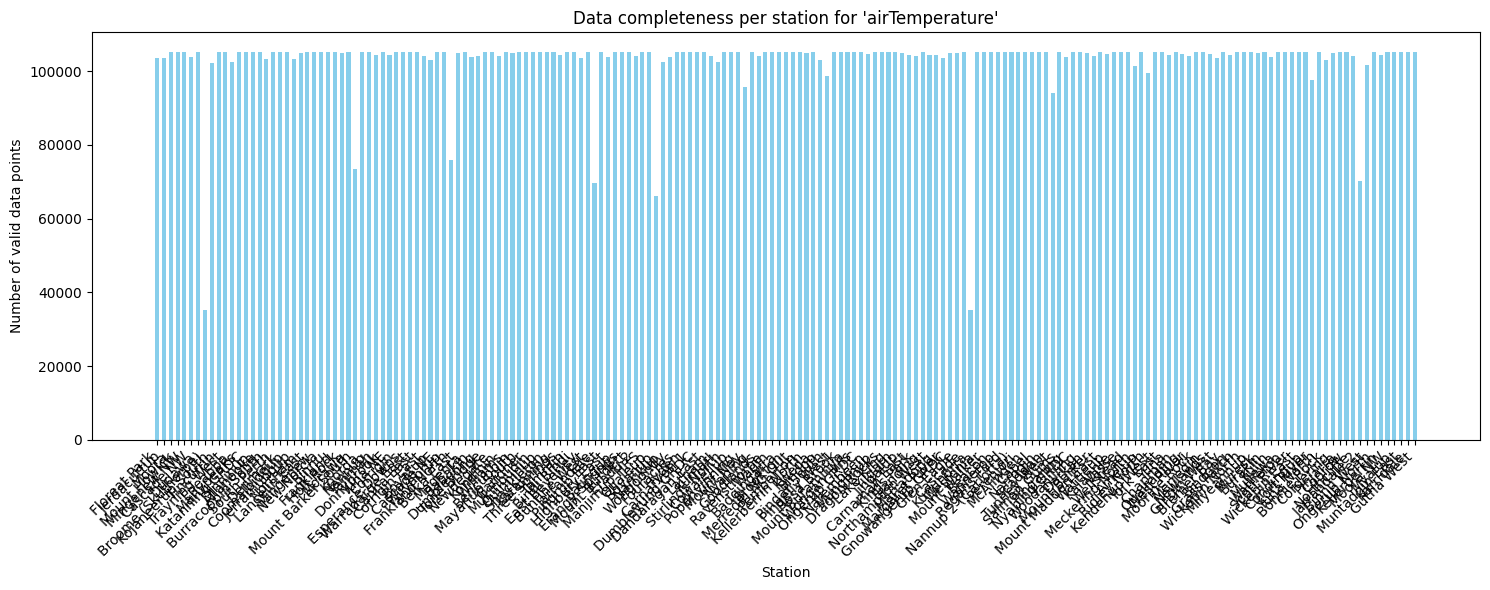

In [67]:
# Count non-NaN entries for a variable (e.g., temperature) per station
var = "airTemperature"  # replace with any variable in your dataset
counts = ds[var].notnull().sum(dim="time").values
stations = ds.station.values

# Create spaced positions for the bars
x_pos = np.arange(len(stations))

plt.figure(figsize=(15,6))
plt.bar(x_pos, counts, width=0.6, color="skyblue")  # bar width adjustable
plt.xticks(x_pos, stations, rotation=45, ha='right')  # slanted labels
plt.xlabel("Station")
plt.ylabel("Number of valid data points")
plt.title(f"Data completeness per station for '{var}'")
plt.tight_layout()  # adjust spacing so labels don’t get cut off
plt.show()

In [68]:
print("\nArray shapes:")
for var, da in ds.data_vars.items():
    print(f"{var}: {da.dims} -> {da.shape}")


ds



Array shapes:
airTemperature: ('station', 'time') -> (185, 105248)
apparentAirTemperature: ('station', 'time') -> (185, 105248)
relativeHumidity: ('station', 'time') -> (185, 105248)
dewPoint: ('station', 'time') -> (185, 105248)
panEvaporation: ('station', 'time') -> (185, 105248)
evapotranspiration_shortCrop: ('station', 'time') -> (185, 105248)
evapotranspiration_tallCrop: ('station', 'time') -> (185, 105248)
richardsonUnits: ('station', 'time') -> (185, 105248)
solarExposure: ('station', 'time') -> (185, 105248)
rainfall: ('station', 'time') -> (185, 105248)
deltaT: ('station', 'time') -> (185, 105248)
wetBulb: ('station', 'time') -> (185, 105248)
frostCondition: ('station', 'time') -> (185, 105248)
heatCondition: ('station', 'time') -> (185, 105248)
wind_3m_speed: ('station', 'time') -> (185, 105248)
wind_3m_degN: ('station', 'time') -> (185, 105248)
wind_10m_speed: ('station', 'time') -> (185, 105248)
wind_10m_degN: ('station', 'time') -> (185, 105248)


<xarray.Dataset> Size: 3GB
Dimensions:                       (station: 185, time: 105248)
Coordinates:
  * station                       (station) <U19 14kB 'Floreat Park' ... 'Gut...
  * time                          (time) datetime64[ns] 842kB 2022-01-01T08:0...
Data variables: (12/18)
    airTemperature                (station, time) float64 156MB 20.4 ... 39.4
    apparentAirTemperature        (station, time) float64 156MB ...
    relativeHumidity              (station, time) float64 156MB ...
    dewPoint                      (station, time) float64 156MB ...
    panEvaporation                (station, time) float64 156MB ...
    evapotranspiration_shortCrop  (station, time) float64 156MB ...
    ...                            ...
    frostCondition                (station, time) float64 156MB ...
    heatCondition                 (station, time) float64 156MB ...
    wind_3m_speed                 (station, time) float64 156MB ...
    wind_3m_degN                  (station, time) float64 156MB ...
    wind_10m_speed                (station, time) float64 156MB ...
    wind_10m_degN                 (station, time) float64 156MB ...
Attributes:
    lat:      -31.9367549
    lon:      115.7911175

Text(0.5, 1.0, 'Air Temperature at ALLANOOKA Station')

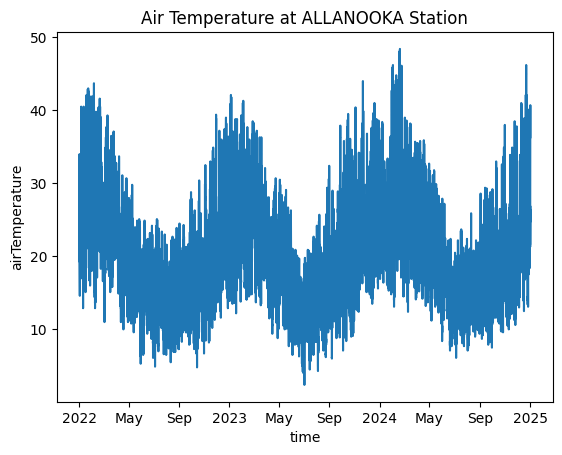

In [69]:
# load only allanooka data
ds_allanooka = ds.sel(station="Allanooka")
ds_allanooka['airTemperature'].plot()
plt.title("Air Temperature at ALLANOOKA Station")

Text(0.5, 1.0, 'Western Australia with Highlighted Region')

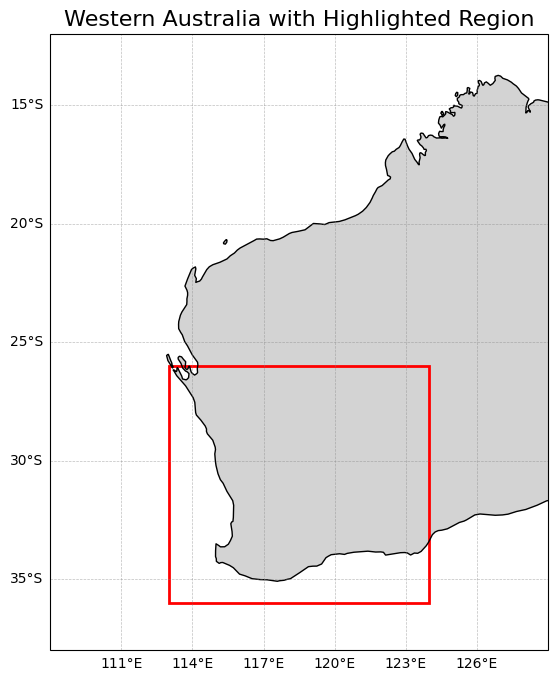

In [70]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.patch import geos_to_path
import matplotlib.patches as mpatches

# Create the map
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Western Australia
ax.set_extent([108, 129, -38, -12], crs=ccrs.PlateCarree())

# Add land, borders, coastline
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Draw the rectangle (Lat min/max: -36.0, -26.0; Lon min/max: 113.0, 124.0)
lat_min, lat_max = -36.0, -26.0
lon_min, lon_max = 113.0, 124.0

rect = mpatches.Rectangle(
    (lon_min, lat_min),  # bottom left corner
    lon_max - lon_min,    # width
    lat_max - lat_min,    # height
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)

# Title
plt.title("Western Australia with Highlighted Region", fontsize=16)

# plt.show()


Stations missing in .nc: ['Dardanup 2', 'Jurien Bay']


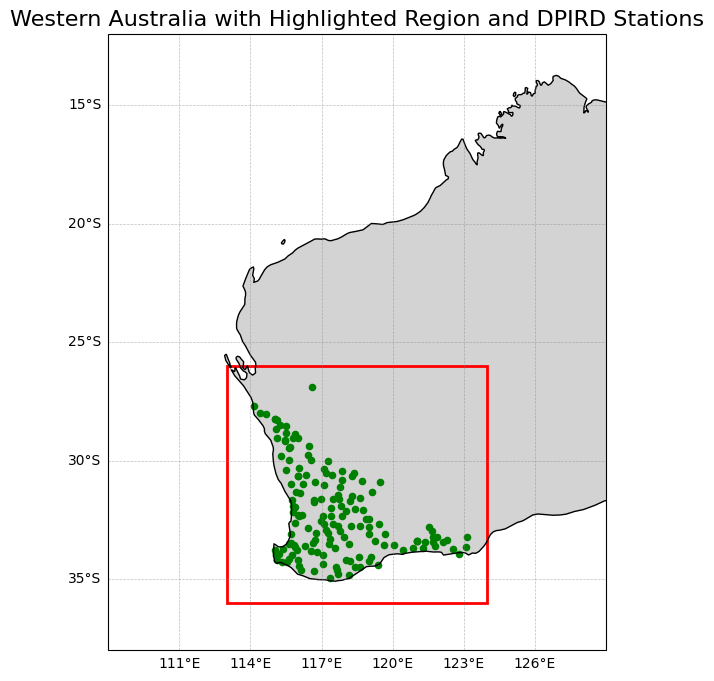

In [71]:
import pandas as pd
import matplotlib.patches as mpatches

# --- CONFIG ---
csv_file = "filtered_dpird_stations.csv"  # your CSV path

# Load CSV
stations_df = pd.read_csv(csv_file)

# Convert NetCDF station names to list of strings
nc_station_list = [str(s) for s in stations]

# Split CSV stations into exists/missing lists
exists_list = []
missing_list = []

for idx, row in stations_df.iterrows():
    name = row['station']
    if name in nc_station_list:
        exists_list.append(row)
    else:
        missing_list.append(name)

# print("Stations that exist in .nc:", [r['station'] for r in exists_list])
print("Stations missing in .nc:", missing_list)

# --- PLOT WA MAP WITH GREEN DOTS ---

# Create the map
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Western Australia
ax.set_extent([108, 129, -38, -12], crs=ccrs.PlateCarree())

# Add land, borders, coastline
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.BORDERS, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, edgecolor='black')

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Draw rectangle (Lat min/max: -36.0, -26.0; Lon min/max: 113.0, 124.0)
lat_min, lat_max = -36.0, -26.0
lon_min, lon_max = 113.0, 124.0
rect = mpatches.Rectangle(
    (lon_min, lat_min), 
    lon_max - lon_min, 
    lat_max - lat_min, 
    linewidth=2, 
    edgecolor='red', 
    facecolor='none',
    transform=ccrs.PlateCarree()
)
ax.add_patch(rect)

# Plot existing stations as green dots
if exists_list:
    exists_df = pd.DataFrame(exists_list)
    ax.scatter(
        exists_df['lon'],
        exists_df['lat'],
        color='green',
        s=20,
        transform=ccrs.PlateCarree()
    )

# Title
plt.title("Western Australia with Highlighted Region and DPIRD Stations", fontsize=16)
plt.show()


/var/folders/ct/z4h43rrs58gd4yrnsy0d4ywr0000gn/T/ipykernel_2691/507008843.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_subset[var_name].resample('H').mean().reset_index()


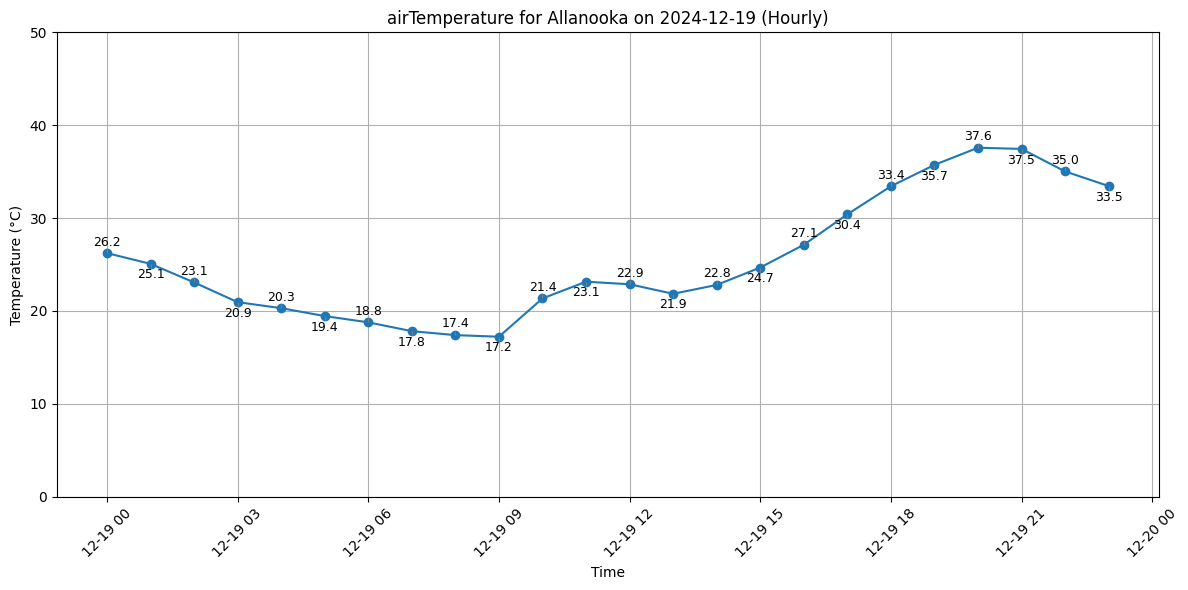

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIG ---
csv_file = "../../2_DPIRD/202412/Allanooka.csv"  # path to CSV
var_name = "airTemperature"
start_time = "2024-12-19 00:00:00"
end_time = "2024-12-19 23:59:00"

# Load CSV and parse 'time' column as datetime
df = pd.read_csv(csv_file, parse_dates=['time'])

# Filter for the time range
mask = (df['time'] >= start_time) & (df['time'] <= end_time)
df_subset = df.loc[mask].reset_index(drop=True)

# Set 'time' as index for resampling
df_subset.set_index('time', inplace=True)

# Resample hourly and take mean
df_hourly = df_subset[var_name].resample('H').mean().reset_index()

# --- PLOT ---
plt.figure(figsize=(12,6))
plt.plot(df_hourly['time'], df_hourly[var_name], marker='o', linestyle='-')

# Label each point with leader lines
for i, row in df_hourly.iterrows():
    # stagger labels up and down to avoid overlap
    y_offset = 0.5 if i % 2 == 0 else -0.5
    label_y = row[var_name] + y_offset
    plt.text(
        row['time'], 
        label_y, 
        f"{row[var_name]:.1f}", 
        ha='center', 
        va='bottom' if y_offset > 0 else 'top',
        fontsize=9
    )
    # draw line from label to point
    plt.plot([row['time'], row['time']], [row[var_name], label_y], color='gray', linestyle='--', linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.ylim(0, 50)
plt.title(f"{var_name} for Allanooka on {start_time[:10]} (Hourly)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
